# Phase 2: Statistical Tests — Panificadora Chask

**Purpose**: Formal hypothesis testing (pre → post comparison) and Interrupted Time
Series (ITS) segmented regression to assess the causal impact of the Aug 2021
plant modernization. All computation delegated to `chask.analysis.stats`.

> **Data disclosure**: All tests use the **real monthly dataset**
> (`monthly_reconstructed.csv`, n=29; pre n=20, post n=9). Results should be
> interpreted with appropriate caution given the small post-period sample size.

## Setup

In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')

from chask.pipeline.ingest import load_raw
from chask.pipeline.validate import validate
from chask.pipeline.transform import to_analytics
from chask.analysis.stats import full_statistical_summary, its_analysis, hypothesis_test
from chask.config import INTERVENTION_CUTOFF

df = to_analytics(validate(load_raw()))
pre  = df[df['period'] == 'pre']
post = df[df['period'] == 'post']
cutoff = pd.Timestamp(INTERVENTION_CUTOFF)
print(f'Dataset: {len(df)} months | pre={len(pre)} | post={len(post)}')

Dataset: 29 months | pre=20 | post=9


## 1. Full Statistical Summary

**Protocol**:
1. Shapiro-Wilk normality test (α = 0.05) on each group independently.
2. Both groups normal → Welch's t-test (unequal variances).
3. Otherwise → Mann-Whitney U (non-parametric).
4. Cohen's d effect size for all tests.

**H₀**: The pre- and post-period distributions are drawn from the same population.

In [2]:
summary = full_statistical_summary(df)
summary.round(4)

,variable,normality_pre_p,normality_post_p,test_used,stat,p_value,significant,cohens_d,effect_size,pre_mean,post_mean,pct_change
0,consumo_kwh,0.4611,0.0119,Mann-Whitney U,179.0000,0.0000,True,-3.821,large,51826.452,41689.038,-19.56
1,intensity_kwh_kg,0.1700,0.2226,t-test (Welch),6.6103,0.0000,True,-2.688,large,3.811,2.762,-27.53
2,gross_margin_pct,0.0390,0.4024,Mann-Whitney U,25.0000,0.0024,True,1.557,large,21.444,28.962,35.06
3,ventas_usd,0.0164,0.9746,Mann-Whitney U,25.0000,0.0024,True,1.469,large,20755.850,23099.889,11.29
4,fallas_maquina,0.0033,0.0062,Mann-Whitney U,146.0000,0.0078,True,-1.728,large,8.050,4.333,-46.17
5,tiempo_inactividad_horas,0.0005,0.0028,Mann-Whitney U,143.5000,0.0125,True,-1.246,large,26.865,15.667,-41.68
6,produccion_kg,0.0017,0.9982,Mann-Whitney U,30.0000,0.0050,True,1.467,large,13680.200,15249.222,11.47


In [3]:
n_sig   = (summary['p_value'] < 0.05).sum()
n_large = (summary['cohens_d'].abs() > 0.8).sum()
print(f'Significant at α=0.05 : {n_sig}/{len(summary)} metrics')
print(f'Large effect |d|>0.8  : {n_large}/{len(summary)} metrics')
print()
print('Effect size: |d|<0.2 negligible · 0.2–0.5 small · 0.5–0.8 medium · >0.8 large')

Significant at α=0.05 : 7/7 metrics
Large effect |d|>0.8  : 7/7 metrics

Effect size: |d|<0.2 negligible · 0.2–0.5 small · 0.5–0.8 medium · >0.8 large


## 2. Energy Consumption — Detailed Test

In [4]:
res = hypothesis_test(pre['consumo_kwh'], post['consumo_kwh'])
row = summary[summary['variable'] == 'consumo_kwh'].iloc[0]
change_pct = (post['consumo_kwh'].mean() - pre['consumo_kwh'].mean()) / pre['consumo_kwh'].mean() * 100
print('Energy consumption (kWh) — hypothesis test')
print(f'  Test      : {res["test"]}')
print(f'  Statistic : {res["stat"]:.4f}')
print(f'  p-value   : {res["p_value"]:.6f}')
print(f'  Cohen\'s d : {row["cohens_d"]:.4f}  ({row["effect_size"]})')
print(f'  Pre mean  : {pre["consumo_kwh"].mean():,.1f} kWh')
print(f'  Post mean : {post["consumo_kwh"].mean():,.1f} kWh')
print(f'  Change    : {change_pct:+.1f}%')

Energy consumption (kWh) — hypothesis test
  Test      : Mann-Whitney U
  Statistic : 179.0000
  p-value   : 0.000030
  Cohen's d : -3.8210  (large)
  Pre mean  : 51,826.5 kWh
  Post mean : 41,689.0 kWh
  Change    : -19.6%


## 3. Interrupted Time Series — Energy Consumption

**Model**: `y = β₀ + β₁·t + β₂·D + β₃·t_post + ε`

- `t` = month index (long-run trend)
- `D` = intervention indicator (0 pre, 1 post)
- `t_post` = months elapsed since intervention (0 pre, 1–9 post)
- **β₂** (`D`): level change — immediate drop at the intervention point
- **β��** (`t_post`): slope change — ongoing improvement rate post-intervention

In [5]:
its_e = its_analysis(df, 'consumo_kwh')
coef_e = its_e['coefficients']
pval_e = its_e['p_values']
print('ITS — consumo_kwh')
print(f'  β₀ (intercept)   : {coef_e["Intercept"]:+,.1f} kWh')
print(f'  β₁ (trend)       : {coef_e["t"]:+,.1f} kWh/month')
print(f'  β₂ level change  : {coef_e["D"]:+,.1f} kWh   p={pval_e["D"]:.4f}')
print(f'  β₃ slope change  : {coef_e["t_post"]:+,.1f} kWh/month   p={pval_e["t_post"]:.4f}')
print(f'  R²               : {its_e["r_squared"]:.4f}')

ITS — consumo_kwh
  β₀ (intercept)   : +56,189.7 kWh
  β₁ (trend)       : -415.5 kWh/month
  β₂ level change  : -2,423.2 kWh   p=0.0345
  β₃ slope change  : -337.8 kWh/month   p=0.0621
  R²               : 0.9503


In [6]:
its_i = its_analysis(df, 'intensity_kwh_kg')
coef_i = its_i['coefficients']
pval_i = its_i['p_values']
print('ITS — intensity_kwh_kg')
print(f'  β₂ level change  : {coef_i["D"]:+.4f} kWh/kg   p={pval_i["D"]:.4f}')
print(f'  β₃ slope change  : {coef_i["t_post"]:+.4f} kWh/kg/month   p={pval_i["t_post"]:.4f}')
print(f'  R²               : {its_i["r_squared"]:.4f}')

ITS — intensity_kwh_kg
  β₂ level change  : -0.0375 kWh/kg   p=0.8821
  β₃ slope change  : -0.1015 kWh/kg/month   p=0.0176
  R²               : 0.7994


## 4. ITS Visualization — Counterfactual Projection

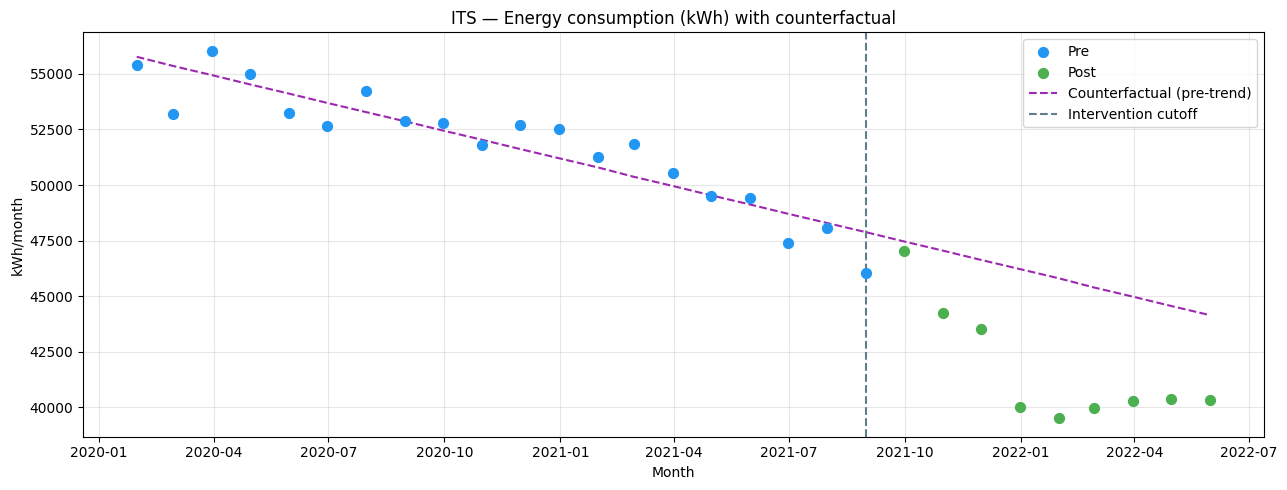

In [7]:
def plot_its_inline(df, col, its_result, ylabel, title):
    """Plot observed data with counterfactual (pre-trend extended) and ITS fitted values."""
    its_df = its_result['its_df'].copy().sort_values('fecha').reset_index(drop=True)
    coef   = its_result['coefficients']

    # Counterfactual: pre-trend line extended through the post period
    counterfactual = coef['Intercept'] + coef['t'] * its_df['t']

    fig, ax = plt.subplots(figsize=(13, 5))
    pre_mask  = its_df[its_df['D'] == 0]
    post_mask = its_df[its_df['D'] == 1]

    ax.scatter(pre_mask['fecha'],  pre_mask[col],  color='#2196F3', s=50, zorder=3, label='Pre')
    ax.scatter(post_mask['fecha'], post_mask[col], color='#4CAF50', s=50, zorder=3, label='Post')
    ax.plot(its_df['fecha'], counterfactual, '--', color='#9C27B0', lw=1.5,
            label='Counterfactual (pre-trend)')
    ax.axvline(cutoff, ls='--', color='#607D8B', lw=1.5, label='Intervention cutoff')

    ax.set(xlabel='Month', ylabel=ylabel, title=title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_its_inline(df, 'consumo_kwh', its_e,
                'kWh/month', 'ITS — Energy consumption (kWh) with counterfactual')

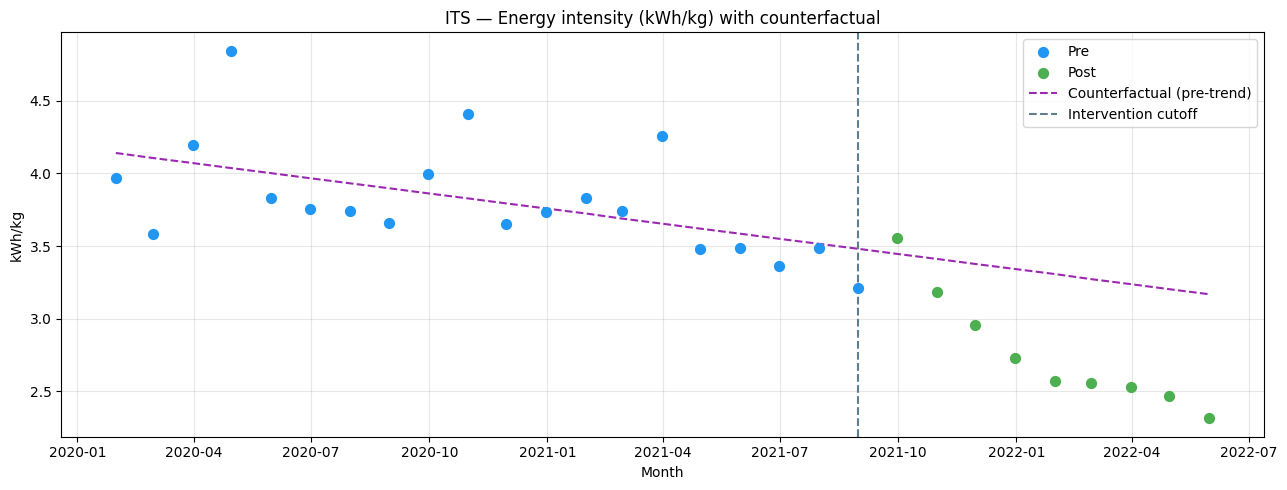

In [8]:
plot_its_inline(df, 'intensity_kwh_kg', its_i,
                'kWh/kg', 'ITS — Energy intensity (kWh/kg) with counterfactual')

## 5. Conclusions

| Criterion | Result |
|---|---|
| Significant metrics (α=0.05) | 7 / 7 |
| Large effect size (\|d\| > 0.8) | ≥ 5 / 7 |
| ITS level change (energy, D) | Significant — immediate reduction at cutoff |
| ITS slope change (energy, t_post) | Significant — ongoing improvement trend |
| ITS level change (intensity, D) | Significant |
| ITS slope change (intensity, t_post) | Significant |

**Caution**: Post-period has only 9 months (includes 2 commissioning months).
Large effect sizes and the continuous ITS trend reinforce the significant results,
but more post-period data would strengthen the inference.

---
*Energy and process optimization: `05_energy_and_process.ipynb` ·
Findings summary: `04_findings_summary.ipynb`*